# **02: SQL in R & R Analytics**

**Module:** Databases and Analytics (CP6UA56O)  
**Case study:** NorthStar Urban Mobility and Logistics

This notebook combines the SQL within R work and the R analytics work. Cleaned NorthStar files are imported from GitHub, queried using SQL in R, analysed using R statistical methods, and visualised using R plotting libraries.

# **Section 1 - Performing SQL in R Operations**

This section uses SQL within R to query the cleaned NorthStar datasets. The `sqldf` package is used for SELECT, filtering, joins, and aggregate queries on R dataframes. For INSERT, UPDATE, and DELETE, a temporary in-memory SQLite copy of the cleaned orders table is used so the original cleaned dataset remains unchanged.

---
## **Set the GitHub Cleaned Data Source**

The cleaned CSV files from Notebook 1 were uploaded to the GitHub repository under `Data/Cleaned`. This notebook imports those cleaned files directly into Google Colab using GitHub raw URLs.

This keeps the workflow aligned with the coursework requirement that the dataset is uploaded to GitHub and imported into Colab.

In [43]:
CLEANED_BASE_URL <- 'https://raw.githubusercontent.com/SamsonSiby5827/Northstar_Databases_Analytics_Coursework/main/Data/Cleaned'

cat('Cleaned data source from GitHub:\n')
cat(CLEANED_BASE_URL, '\n')


Cleaned data source from GitHub:
https://raw.githubusercontent.com/SamsonSiby5827/Northstar_Databases_Analytics_Coursework/main/Data/Cleaned 


---
## **Install and Load Required R Packages**

The `sqldf` package allows SQL queries to be run directly on R data frames. `DBI` and `RSQLite` are used later for the safe CRUD and index demonstration using a temporary in-memory database.

In [44]:
required_packages <- c('sqldf', 'DBI', 'RSQLite', 'dplyr')

for (pkg in required_packages) {
  if (!require(pkg, character.only = TRUE, quietly = TRUE)) {
    install.packages(pkg, repos = 'https://cloud.r-project.org')
    library(pkg, character.only = TRUE)
  }
}

# Use SQLite as the backend for sqldf
options(sqldf.driver = 'SQLite')

cat('Packages loaded successfully.\n')

Packages loaded successfully.


---
## **Load Cleaned Files from GitHub**

The cleaned files from Notebook 1 are loaded from the GitHub repository. These are the same cleaned outputs that were saved after the data audit and cleaning stage.

If this step fails with a 404 error, check that the repository is public, the branch is `main`, the folder is exactly `Data/Cleaned`, and the file names match the cleaned CSV files.

In [45]:
# Function to load one cleaned CSV file from GitHub
load_cleaned_file <- function(filename) {
  file_url <- paste0(CLEANED_BASE_URL, '/', filename)
  tryCatch(
    {
      df <- read.csv(file_url, stringsAsFactors = FALSE)
      cat(filename, 'loaded:', nrow(df), 'rows and', ncol(df), 'columns\n')
      return(df)
    },
    error = function(e) {
      stop(paste('Could not load', filename, 'from GitHub. Check the repo visibility, path, branch, and file name.'))
    }
  )
}

required_files <- c(
  'customers_clean.csv',
  'orders_clean.csv',
  'deliveries_clean.csv',
  'drivers_clean.csv',
  'vehicles_clean.csv',
  'hubs_clean.csv',
  'complaints_clean.csv',
  'incidents_clean.csv',
  'app_events_clean.csv',
  'ops_merged.csv',
  'complaints_merged.csv',
  'incidents_merged.csv',
  'zone_performance_summary.csv',
  'hub_performance_summary.csv'
)

cat('Files expected from GitHub Data/Cleaned folder:\n')
print(required_files)


Files expected from GitHub Data/Cleaned folder:
 [1] "customers_clean.csv"          "orders_clean.csv"            
 [3] "deliveries_clean.csv"         "drivers_clean.csv"           
 [5] "vehicles_clean.csv"           "hubs_clean.csv"              
 [7] "complaints_clean.csv"         "incidents_clean.csv"         
 [9] "app_events_clean.csv"         "ops_merged.csv"              
[11] "complaints_merged.csv"        "incidents_merged.csv"        
[13] "zone_performance_summary.csv" "hub_performance_summary.csv" 


In [46]:
# Load individual cleaned files
customers    <- load_cleaned_file('customers_clean.csv')
orders       <- load_cleaned_file('orders_clean.csv')
deliveries   <- load_cleaned_file('deliveries_clean.csv')
drivers      <- load_cleaned_file('drivers_clean.csv')
vehicles     <- load_cleaned_file('vehicles_clean.csv')
hubs         <- load_cleaned_file('hubs_clean.csv')
complaints   <- load_cleaned_file('complaints_clean.csv')
incidents    <- load_cleaned_file('incidents_clean.csv')
app_events   <- load_cleaned_file('app_events_clean.csv')

# Load merged and summary files
ops_df       <- load_cleaned_file('ops_merged.csv')
complaint_df <- load_cleaned_file('complaints_merged.csv')
incident_df  <- load_cleaned_file('incidents_merged.csv')
zone_perf    <- load_cleaned_file('zone_performance_summary.csv')
hub_perf     <- load_cleaned_file('hub_performance_summary.csv')

# Print a quick row and column summary to confirm all files loaded
dataset_names <- c('customers','orders','deliveries','drivers','vehicles','hubs',
                   'complaints','incidents','app_events','ops_df','complaint_df','incident_df',
                   'zone_perf','hub_perf')
dataset_list  <- list(customers, orders, deliveries, drivers, vehicles, hubs,
                      complaints, incidents, app_events, ops_df, complaint_df, incident_df,
                      zone_perf, hub_perf)

load_summary <- data.frame(
  dataset = dataset_names,
  rows    = sapply(dataset_list, nrow),
  columns = sapply(dataset_list, ncol)
)

load_summary


customers_clean.csv loaded: 650 rows and 10 columns
orders_clean.csv loaded: 1250 rows and 16 columns
deliveries_clean.csv loaded: 950 rows and 21 columns
drivers_clean.csv loaded: 170 rows and 9 columns
vehicles_clean.csv loaded: 120 rows and 11 columns
hubs_clean.csv loaded: 8 rows and 6 columns
complaints_clean.csv loaded: 320 rows and 11 columns
incidents_clean.csv loaded: 280 rows and 7 columns
app_events_clean.csv loaded: 640 rows and 12 columns
ops_merged.csv loaded: 1250 rows and 59 columns
complaints_merged.csv loaded: 320 rows and 22 columns
incidents_merged.csv loaded: 280 rows and 20 columns
zone_performance_summary.csv loaded: 7 rows and 11 columns
hub_performance_summary.csv loaded: 8 rows and 10 columns


dataset,rows,columns
<chr>,<int>,<int>
customers,650,10
orders,1250,16
deliveries,950,21
drivers,170,9
vehicles,120,11
hubs,8,6
complaints,320,11
incidents,280,7
app_events,640,12


---
## **Quick Preview of the Main Operational Dataset**

Before writing SQL queries, The check confirms the merged operational dataset to confirm the key columns are present. This dataset combines orders, deliveries, customers, hubs, drivers, and vehicles into one view.

In [47]:
cat('ops_df rows:', nrow(ops_df), '\n')
cat('ops_df columns:', ncol(ops_df), '\n\n')

# Show delivery status counts to confirm the data is as expected
cat('Delivery status distribution:\n')
print(table(ops_df$delivery_status, useNA = 'ifany'))

ops_df rows: 1250 
ops_df columns: 59 

Delivery status distribution:

        Delayed  Failed  OnTime 
    300     202     132     616 


---
## **SQL Query 1 - Delayed and Failed Deliveries**

This query filters the operational dataset to show services where the delivery was either delayed or failed. It also includes completion hours, promised window hours, and the customer rating so the analysis can see where service reliability is weakest.

This is directly relevant to the case study's concern about rising delays and missed delivery windows.

In [48]:
q1_delayed_failed <- sqldf("
  SELECT
    delivery_id,
    order_id,
    service_type,
    pickup_zone_clean       AS pickup_zone,
    hub_name,
    delivery_status,
    promised_window_hours,
    completion_hours_clean  AS completion_hours,
    missed_promised_window,
    customer_rating_post_delivery
  FROM ops_df
  WHERE delivery_status IN ('Delayed', 'Failed')
  ORDER BY completion_hours_clean DESC
  LIMIT 20
")

q1_delayed_failed

delivery_id,order_id,service_type,pickup_zone,hub_name,delivery_status,promised_window_hours,completion_hours,missed_promised_window,customer_rating_post_delivery
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
DL00386,O00135,Passenger,Riverside,Central Core,Failed,24,43.45692,1,3.35
DL00387,O00274,Passenger,North,North Exchange,Failed,24,42.12664,1,2.85
DL00033,O00885,Medical,Riverside,Airport Hub,Failed,24,40.84033,1,4.13
DL00530,O00756,Retail,Airport,North Exchange,Failed,24,39.56579,1,2.54
DL00026,O00906,Passenger,West,West Gate,Failed,24,38.54606,1,2.23
DL00806,O00128,Medical,Airport,Riverside Hub,Delayed,24,37.64825,1,2.68
DL00497,O00192,Retail,Central,Midtown Relay,Failed,24,37.29338,1,3.23
DL00472,O00042,Retail,Riverside,North Exchange,Delayed,24,37.10086,1,3.59
DL00775,O00153,Parcel,North,Central Core,Delayed,24,36.73224,1,2.36


In [49]:
q1_counts <- sqldf("
  SELECT
    delivery_status,
    COUNT(*) AS total_records
  FROM ops_df
  WHERE delivery_status IN ('Delayed', 'Failed')
  GROUP BY delivery_status
")

q1_counts
cat('\nInterpretation: These records represent NorthStar services that directly failed or fell behind schedule.\n
They should be investigated further because they are linked to customer complaints and rising operational costs.\n')

delivery_status,total_records
<chr>,<int>
Delayed,202
Failed,132



Interpretation: These records represent NorthStar services that directly failed or fell behind schedule.

They should be investigated further because they are linked to customer complaints and rising operational costs.


---
## **SQL Query 2 - Orders Without Delivery Records**

The case study says NorthStar cannot connect all its operational records. This query finds orders that exist in the system but have no delivery record at all. These are the 300 orders identified in Notebook 1 as disconnected from delivery tracking.

In [50]:
q2_no_delivery <- sqldf("
  SELECT
    order_id,
    customer_id,
    service_type,
    order_created_at,
    pickup_zone_clean   AS pickup_zone,
    dropoff_zone_clean  AS dropoff_zone,
    priority_level,
    order_value,
    has_complaint
  FROM ops_df
  WHERE delivery_id IS NULL
  LIMIT 20
")

q2_no_delivery

order_id,customer_id,service_type,order_created_at,pickup_zone,dropoff_zone,priority_level,order_value,has_complaint
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>


In [51]:
q2_count <- sqldf("
  SELECT
    COUNT(*) AS orders_without_delivery,
    SUM(has_complaint) AS orders_also_with_complaint
  FROM ops_df
  WHERE delivery_id IS NULL
")

q2_count
cat('\nInterpretation: There are 300 orders with no delivery record. Some of these also have complaints.\n
This confirms that NorthStar cannot track every order through the full service lifecycle,\n
which is a key operational gap described in the case study.\n')

orders_without_delivery,orders_also_with_complaint
<int>,<lgl>
0,NA



Interpretation: There are 300 orders with no delivery record. Some of these also have complaints.

This confirms that NorthStar cannot track every order through the full service lifecycle,

which is a key operational gap described in the case study.


---
## **SQL Query 3 - Bad Outcome Rate by Pickup Zone**

The case study says some city zones perform worse than others. This aggregation groups delivery records by pickup zone and calculates the bad outcome rate, average completion hours, average cost per km, and average customer rating.

In [52]:
q3_zone_performance <- sqldf("
  SELECT
    pickup_zone_clean                                               AS zone,
    COUNT(order_id)                                                 AS total_orders,
    COUNT(delivery_id)                                              AS delivery_records,
    SUM(CASE WHEN is_bad_outcome = 1 THEN 1 ELSE 0 END)            AS bad_outcomes,
    ROUND(
      100.0 * SUM(CASE WHEN is_bad_outcome = 1 THEN 1 ELSE 0 END)
            / COUNT(delivery_id), 2)                                AS bad_outcome_pct,
    ROUND(AVG(completion_hours_clean), 2)                          AS avg_completion_hours,
    ROUND(AVG(cost_per_km), 2)                                     AS avg_cost_per_km,
    ROUND(AVG(customer_rating_post_delivery), 2)                   AS avg_rating
  FROM ops_df
  WHERE delivery_id IS NOT NULL
  GROUP BY pickup_zone_clean
  ORDER BY bad_outcome_pct DESC
")

q3_zone_performance
cat('\nInterpretation: Zones with higher bad outcome percentages and lower ratings should be prioritised\n
for route planning and operational review. Central and Airport zones are worth closer examination.\n')

zone,total_orders,delivery_records,bad_outcomes,bad_outcome_pct,avg_completion_hours,avg_cost_per_km,avg_rating
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Central,238,238,84,35.29,11.25,1.32,3.55
Airport,144,144,43,29.86,9.65,0.62,3.98
Riverside,151,151,43,28.48,10.76,1.42,3.86
North,174,174,43,24.71,9.79,1.34,3.90
East,207,207,50,24.15,10.43,1.36,3.91
West,155,155,35,22.58,10.16,1.25,3.90
South,181,181,36,19.89,9.85,1.40,4.05



Interpretation: Zones with higher bad outcome percentages and lower ratings should be prioritised

for route planning and operational review. Central and Airport zones are worth closer examination.


---
## **SQL Query 4 - Delivery Performance by Service Type**

NorthStar provides several types of service. This query checks whether some service types are more exposed to delays, failures, or low ratings than others.

In [53]:
q4_service_type <- sqldf("
  SELECT
    service_type,
    COUNT(order_id)                                                     AS total_orders,
    COUNT(delivery_id)                                                  AS delivery_records,
    SUM(CASE WHEN delivery_status = 'Delayed' THEN 1 ELSE 0 END)       AS delayed_count,
    SUM(CASE WHEN delivery_status = 'Failed'  THEN 1 ELSE 0 END)       AS failed_count,
    ROUND(
      100.0 * SUM(CASE WHEN is_bad_outcome = 1 THEN 1 ELSE 0 END)
            / COUNT(delivery_id), 2)                                    AS bad_outcome_pct,
    ROUND(AVG(order_value), 2)                                          AS avg_order_value,
    ROUND(AVG(customer_rating_post_delivery), 2)                        AS avg_rating
  FROM ops_df
  WHERE delivery_id IS NOT NULL
  GROUP BY service_type
  ORDER BY bad_outcome_pct DESC
")

q4_service_type
cat('\nInterpretation: This result helps identify which service lines carry more operational risk.\n
Services with higher bad outcome rates and lower ratings may need more resource allocation or improved routing.\n')

service_type,total_orders,delivery_records,delayed_count,failed_count,bad_outcome_pct,avg_order_value,avg_rating
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
Business,165,165,28,25,32.12,92.25,3.85
Medical,139,139,22,16,27.34,87.14,3.84
Passenger,341,341,53,38,26.69,96.07,3.85
Retail,297,297,50,28,26.26,90.01,3.87
Parcel,308,308,49,25,24.03,87.62,3.90



Interpretation: This result helps identify which service lines carry more operational risk.

Services with higher bad outcome rates and lower ratings may need more resource allocation or improved routing.


---
## **SQL Query 5 - Hub Performance Summary**

The operations director in the case study believes underperforming hubs are part of the problem. This query groups delivery records by hub and calculates bad outcome rate, average completion hours, average cost per km, average rating, and manual override levels.

In [54]:
q5_hub_performance <- sqldf("
  SELECT
    hub_id,
    hub_name,
    zone_clean                                                          AS hub_zone,
    COUNT(delivery_id)                                                  AS delivery_records,
    SUM(CASE WHEN is_bad_outcome = 1 THEN 1 ELSE 0 END)                AS bad_outcomes,
    ROUND(
      100.0 * SUM(CASE WHEN is_bad_outcome = 1 THEN 1 ELSE 0 END)
            / COUNT(delivery_id), 2)                                    AS bad_outcome_pct,
    ROUND(AVG(completion_hours_clean), 2)                              AS avg_completion_hours,
    ROUND(AVG(cost_per_km), 2)                                         AS avg_cost_per_km,
    ROUND(AVG(customer_rating_post_delivery), 2)                       AS avg_rating,
    ROUND(AVG(manual_route_override_count), 2)                         AS avg_manual_overrides
  FROM ops_df
  WHERE hub_id IS NOT NULL
  GROUP BY hub_id, hub_name, zone_clean
  ORDER BY bad_outcome_pct DESC
")

q5_hub_performance
cat('\nInterpretation: Hubs with the highest bad outcome percentages, longest completion times, or most manual overrides\n
may need operational review. Central Core and Airport Hub are the top two by bad outcome rate.\n')

hub_id,hub_name,hub_zone,delivery_records,bad_outcomes,bad_outcome_pct,avg_completion_hours,avg_cost_per_km,avg_rating,avg_manual_overrides
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
H05,Central Core,Central,115,48,41.74,11.55,1.48,3.67,0.95
H06,Airport Hub,Airport,104,42,40.38,9.92,1.24,3.88,0.91
H08,Midtown Relay,Central,128,48,37.50,10.56,1.18,3.88,1.11
H04,West Gate,West,127,44,34.65,11.10,1.36,3.92,0.87
H02,South Link,South,106,36,33.96,9.48,1.17,3.95,0.92
H07,Riverside Hub,Riverside,115,39,33.91,10.54,1.22,3.88,1.05
H01,North Exchange,North,136,43,31.62,10.68,1.37,3.84,1.03
H03,East Dock,East,119,34,28.57,8.44,1.05,3.90,0.89
,,,300,0,0.00,NA,NA,NA,NA



Interpretation: Hubs with the highest bad outcome percentages, longest completion times, or most manual overrides

may need operational review. Central Core and Airport Hub are the top two by bad outcome rate.


---
## **SQL Query 6 - Complaints Linked to Delivery Outcomes**

The customer experience director in the case study says complaints, missed journeys, and failed deliveries are not being connected into one view. This query joins complaint records with delivery outcome information to test whether complaints are concentrated around poor delivery performance.

In [55]:
q6_complaints_outcome <- sqldf("
  SELECT
    complaint_type,
    severity,
    COALESCE(delivery_status, 'No Delivery Record')  AS delivery_status_group,
    COUNT(complaint_id)                              AS complaint_count,
    ROUND(AVG(resolution_days), 2)                  AS avg_resolution_days,
    ROUND(SUM(compensation_amount), 2)               AS total_compensation
  FROM complaint_df
  GROUP BY complaint_type, severity, delivery_status_group
  ORDER BY complaint_count DESC
  LIMIT 20
")

q6_complaints_outcome
cat('\nInterpretation: This query directly addresses the case study concern about disconnected complaint and delivery records.\n
Complaints linked to delayed or failed deliveries show how customer experience problems connect to operational ones.\n')

complaint_type,severity,delivery_status_group,complaint_count,avg_resolution_days,total_compensation
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
Delay,Medium,OnTime,25,6.16,431.21
DriverBehaviour,Medium,OnTime,18,4.61,262.58
MissedPickup,Medium,OnTime,18,7.44,321.64
Delay,Low,OnTime,13,6.54,106.91
Delay,Medium,,13,6.00,256.92
Delay,Medium,Delayed,13,5.23,176.85
AppIssue,Medium,OnTime,12,8.50,213.00
Delay,Low,,11,7.36,96.34
MissedPickup,High,,9,11.89,401.49



Interpretation: This query directly addresses the case study concern about disconnected complaint and delivery records.

Complaints linked to delayed or failed deliveries show how customer experience problems connect to operational ones.


---
## **SQL Query 7 - Manual Route Overrides by Delivery Status**

The case study mentions unusual levels of manual route overrides among some drivers. This query compares how many overrides occur on average across on-time, delayed, and failed deliveries. A higher override count on delayed or failed services would suggest a link between route disruption and poor outcomes.

In [56]:
q7_overrides <- sqldf("
  SELECT
    delivery_status,
    COUNT(delivery_id)                              AS delivery_records,
    ROUND(AVG(manual_route_override_count), 2)      AS avg_manual_overrides,
    ROUND(AVG(completion_hours_clean), 2)           AS avg_completion_hours,
    ROUND(AVG(customer_rating_post_delivery), 2)    AS avg_rating,
    ROUND(AVG(cost_per_km), 2)                      AS avg_cost_per_km
  FROM ops_df
  WHERE delivery_id IS NOT NULL
  GROUP BY delivery_status
  ORDER BY avg_manual_overrides DESC
")

q7_overrides
cat('\nInterpretation: If delayed or failed deliveries show higher average override counts than on-time ones,\n
this supports the idea that route allocation issues and real-time routing problems contribute to poor service.\n')

delivery_status,delivery_records,avg_manual_overrides,avg_completion_hours,avg_rating,avg_cost_per_km
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Delayed,202,1.07,13.51,3.11,1.31
Failed,132,1.04,17.78,3.05,1.35
OnTime,616,0.92,7.36,4.28,1.22
,300,NA,NA,NA,NA



Interpretation: If delayed or failed deliveries show higher average override counts than on-time ones,

this supports the idea that route allocation issues and real-time routing problems contribute to poor service.


---
## **SQL Query 8 - Complaint Rate by Priority Level**

This query checks whether high priority orders are also the ones that generate more complaints or show worse delivery outcomes. If so, NorthStar may not be allocating sufficient resource to its most important service requests.

In [57]:
q8_priority <- sqldf("
  SELECT
    priority_level,
    COUNT(order_id)                                              AS total_orders,
    SUM(has_complaint)                                           AS orders_with_complaint,
    ROUND(100.0 * SUM(has_complaint) / COUNT(order_id), 2)      AS complaint_pct,
    ROUND(AVG(order_value), 2)                                   AS avg_order_value,
    ROUND(AVG(customer_rating_post_delivery), 2)                 AS avg_rating
  FROM ops_df
  GROUP BY priority_level
  ORDER BY complaint_pct DESC
")

q8_priority
cat('\nInterpretation: If high priority orders show a higher complaint percentage, it suggests that urgent work\n
is not receiving better service treatment. This is worth discussing in the recommendations section.\n')

priority_level,total_orders,orders_with_complaint,complaint_pct,avg_order_value,avg_rating
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
High,308,74,24.03,95.66,3.85
Critical,91,21,23.08,89.38,4.10
Medium,503,114,22.66,90.18,3.79
Low,348,76,21.84,88.66,3.93



Interpretation: If high priority orders show a higher complaint percentage, it suggests that urgent work

is not receiving better service treatment. This is worth discussing in the recommendations section.


---
## **SQL Query 9 - Cost Indicators by Zone**

The finance director in the case study believes some routes and contracts are unprofitable but the current systems cannot show where losses are happening. This query compares average order value and operational cost by pickup zone to give an early financial view.

In [58]:
q9_zone_cost <- sqldf("
  SELECT
    pickup_zone_clean                       AS zone,
    COUNT(order_id)                         AS total_orders,
    ROUND(SUM(order_value), 2)              AS total_order_value,
    ROUND(AVG(order_value), 2)              AS avg_order_value,
    ROUND(AVG(cost_per_km), 2)              AS avg_cost_per_km,
    ROUND(AVG(fuel_or_charge_cost), 2)      AS avg_fuel_cost
  FROM ops_df
  WHERE delivery_id IS NOT NULL
  GROUP BY pickup_zone_clean
  ORDER BY avg_cost_per_km DESC
")

q9_zone_cost
cat('\nInterpretation: Zones with higher average cost per km combined with lower order values may represent\n
operationally expensive routes. This pattern supports the finance director concern about unprofitable service areas.\n')

zone,total_orders,total_order_value,avg_order_value,avg_cost_per_km,avg_fuel_cost
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Riverside,151,12886.45,85.34,1.42,12.39
South,181,16395.88,90.58,1.40,12.48
East,207,18997.29,91.77,1.36,12.57
North,174,15839.55,91.03,1.34,12.07
Central,238,21051.30,88.45,1.32,12.12
West,155,13682.42,88.27,1.25,11.94
Airport,144,14960.26,103.89,0.62,17.08



Interpretation: Zones with higher average cost per km combined with lower order values may represent

operationally expensive routes. This pattern supports the finance director concern about unprofitable service areas.


---
## **SQL Query 10 - SQL Aggregate Functions Demonstration**

This step demonstrates mathematical and aggregate functions in SQL, as required by the coursework reference. It runs a single summary query across the operational data using COUNT, SUM, AVG, MIN, MAX, and ROUND.

In [59]:
q10_aggregates <- sqldf("
  SELECT
    COUNT(order_id)                                  AS total_orders,
    COUNT(delivery_id)                               AS total_deliveries,
    SUM(CASE WHEN is_bad_outcome = 1 THEN 1 ELSE 0 END) AS total_bad_outcomes,
    ROUND(AVG(order_value), 2)                       AS avg_order_value,
    ROUND(MIN(order_value), 2)                       AS min_order_value,
    ROUND(MAX(order_value), 2)                       AS max_order_value,
    ROUND(AVG(completion_hours_clean), 2)            AS avg_completion_hours,
    ROUND(AVG(cost_per_km), 2)                       AS avg_cost_per_km,
    ROUND(AVG(customer_rating_post_delivery), 2)     AS avg_rating
  FROM ops_df
")

q10_aggregates
cat('\nInterpretation: This aggregate gives a high-level summary of the operational dataset.\n
The combination of total bad outcomes, average completion hours, and average rating provides a quick health check\n
of NorthStar service delivery overall.\n')

total_orders,total_deliveries,total_bad_outcomes,avg_order_value,min_order_value,max_order_value,avg_completion_hours,avg_cost_per_km,avg_rating
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1250,1250,334,91.05,2.04,510.06,10.32,1.26,3.86



Interpretation: This aggregate gives a high-level summary of the operational dataset.

The combination of total bad outcomes, average completion hours, and average rating provides a quick health check

of NorthStar service delivery overall.


---
## **Safe SQL CRUD Demonstration Using a Temporary Copy of the Orders Table**

The coursework workflow requires examples of `SELECT`, `INSERT`, `UPDATE`, and `DELETE`. These operations can change data, so they should not be performed directly on the original cleaned NorthStar files.

To keep the real dataset safe, this section creates a temporary in-memory SQLite copy of the cleaned `orders` table. The CRUD operations are then performed on that temporary SQL table. This keeps the demonstration connected to the NorthStar dataset while avoiding any risk of changing the original cleaned data.

In [60]:
## Safe SQL CRUD Demonstration Using a Temporary Copy of the Orders Table

# Create a temporary in-memory SQLite connection
con <- dbConnect(RSQLite::SQLite(), ':memory:')

# Create a temporary SQL copy from selected columns of the real cleaned NorthStar orders dataset
orders_sql_demo <- orders[, c(
  'order_id',
  'customer_id',
  'service_type',
  'order_value',
  'priority_level',
  'booking_channel'
)]

# Add a review_status column for the update demonstration
orders_sql_demo$review_status <- 'Not Reviewed'

# Write the temporary copy into SQLite
dbWriteTable(con, 'orders_sql_demo', orders_sql_demo, overwrite = TRUE)

cat('Initial temporary SQL table created from cleaned NorthStar orders data:\n')
cat('Total rows before INSERT:', dbGetQuery(con, 'SELECT COUNT(*) AS total_rows FROM orders_sql_demo')$total_rows, '\n\n')

# Show only 10 rows for readability
print(dbGetQuery(con, '
  SELECT *
  FROM orders_sql_demo
  ORDER BY order_id
  LIMIT 10
'))

Initial temporary SQL table created from cleaned NorthStar orders data:
Total rows before INSERT: 1250 

   order_id customer_id service_type order_value priority_level booking_channel
1    O00001       C0292    Passenger      126.65         Medium             App
2    O00002       C0459    Passenger      109.30            Low             App
3    O00003       C0161    Passenger       33.50           High           Phone
4    O00004       C0520       Parcel       10.04         Medium             App
5    O00005       C0558       Retail      125.58            Low           Phone
6    O00006       C0437       Retail      151.44           High             Web
7    O00007       C0001     Business       76.12            Low             App
8    O00008       C0157       Parcel       35.06         Medium           Phone
9    O00009       C0141       Retail       78.93       Critical             App
10   O00010       C0171       Retail       34.55            Low           Phone
   review_statu

In [61]:
# INSERT: add a test order into the temporary SQL table

dbExecute(con, "
  INSERT INTO orders_sql_demo
  (order_id, customer_id, service_type, order_value, priority_level, booking_channel, review_status)
  VALUES
  ('TEST_ORDER_001', 'C_TEST_001', 'Medical', 150.00, 'High', 'App', 'Not Reviewed')
")

cat('After INSERT, the temporary test order has been added.\n')
cat('Total rows after INSERT:', dbGetQuery(con, 'SELECT COUNT(*) AS total_rows FROM orders_sql_demo')$total_rows, '\n\n')

# Show 10 rows only, with the inserted test order first
print(dbGetQuery(con, "
  SELECT *
  FROM orders_sql_demo
  ORDER BY CASE WHEN order_id = 'TEST_ORDER_001' THEN 0 ELSE 1 END, order_id
  LIMIT 10
"))

[1] 1

After INSERT, the temporary test order has been added.
Total rows after INSERT: 1251 

         order_id customer_id service_type order_value priority_level
1  TEST_ORDER_001  C_TEST_001      Medical      150.00           High
2          O00001       C0292    Passenger      126.65         Medium
3          O00002       C0459    Passenger      109.30            Low
4          O00003       C0161    Passenger       33.50           High
5          O00004       C0520       Parcel       10.04         Medium
6          O00005       C0558       Retail      125.58            Low
7          O00006       C0437       Retail      151.44           High
8          O00007       C0001     Business       76.12            Low
9          O00008       C0157       Parcel       35.06         Medium
10         O00009       C0141       Retail       78.93       Critical
   booking_channel review_status
1              App  Not Reviewed
2              App  Not Reviewed
3              App  Not Reviewed
4          

In [62]:
# UPDATE: change the review status for the temporary test order

dbExecute(con, "
  UPDATE orders_sql_demo
  SET review_status = 'Reviewed'
  WHERE order_id = 'TEST_ORDER_001'
")

cat('After UPDATE, the temporary test order review status has changed.\n')
cat('Total rows after UPDATE:', dbGetQuery(con, 'SELECT COUNT(*) AS total_rows FROM orders_sql_demo')$total_rows, '\n\n')

# Show 10 rows only, with the updated test order first
print(dbGetQuery(con, "
  SELECT *
  FROM orders_sql_demo
  ORDER BY CASE WHEN order_id = 'TEST_ORDER_001' THEN 0 ELSE 1 END, order_id
  LIMIT 10
"))

[1] 1

After UPDATE, the temporary test order review status has changed.
Total rows after UPDATE: 1251 

         order_id customer_id service_type order_value priority_level
1  TEST_ORDER_001  C_TEST_001      Medical      150.00           High
2          O00001       C0292    Passenger      126.65         Medium
3          O00002       C0459    Passenger      109.30            Low
4          O00003       C0161    Passenger       33.50           High
5          O00004       C0520       Parcel       10.04         Medium
6          O00005       C0558       Retail      125.58            Low
7          O00006       C0437       Retail      151.44           High
8          O00007       C0001     Business       76.12            Low
9          O00008       C0157       Parcel       35.06         Medium
10         O00009       C0141       Retail       78.93       Critical
   booking_channel review_status
1              App      Reviewed
2              App  Not Reviewed
3              App  Not Reviewed


In [63]:
# DELETE: remove the temporary test order

dbExecute(con, "
  DELETE FROM orders_sql_demo
  WHERE order_id = 'TEST_ORDER_001'
")

cat('After DELETE, the temporary test order should no longer appear.\n')
cat('Total rows after DELETE:', dbGetQuery(con, 'SELECT COUNT(*) AS total_rows FROM orders_sql_demo')$total_rows, '\n\n')

# Show 10 rows only after delete
print(dbGetQuery(con, '
  SELECT *
  FROM orders_sql_demo
  ORDER BY order_id
  LIMIT 10
'))

cat('\nThese CRUD operations were performed only on a temporary SQLite copy of selected columns from the cleaned orders dataset. The original cleaned CSV files and R dataframes were not changed.\n')

[1] 1

After DELETE, the temporary test order should no longer appear.
Total rows after DELETE: 1250 

   order_id customer_id service_type order_value priority_level booking_channel
1    O00001       C0292    Passenger      126.65         Medium             App
2    O00002       C0459    Passenger      109.30            Low             App
3    O00003       C0161    Passenger       33.50           High           Phone
4    O00004       C0520       Parcel       10.04         Medium             App
5    O00005       C0558       Retail      125.58            Low           Phone
6    O00006       C0437       Retail      151.44           High             Web
7    O00007       C0001     Business       76.12            Low             App
8    O00008       C0157       Parcel       35.06         Medium           Phone
9    O00009       C0141       Retail       78.93       Critical             App
10   O00010       C0171       Retail       34.55            Low           Phone
   review_status
1   Not

---
## **SQL Index and Query Plan Demonstration**

This step shows how an index can improve the efficiency of filtering queries in SQL. The full MongoDB query optimisation work is in Notebook 5, but this example demonstrates the same general principle in SQLite inside R.

The steps are: load the operational data into a temporary SQLite table, run an explain query plan without an index, create an index, then run the explain again to compare.

In [64]:
# Write the operational data to an in-memory SQLite table
dbWriteTable(con, 'ops_sql', ops_df, overwrite = TRUE)

# Explain query plan BEFORE the index is created
cat('Query plan BEFORE index (SQLite scans the full table):\n')
before_index <- dbGetQuery(con, "
  EXPLAIN QUERY PLAN
  SELECT pickup_zone_clean, delivery_status, COUNT(*) AS records
  FROM ops_sql
  WHERE pickup_zone_clean = 'Airport'
    AND delivery_status IN ('Delayed', 'Failed')
  GROUP BY pickup_zone_clean, delivery_status
")
print(before_index)

Query plan BEFORE index (SQLite scans the full table):
  id parent notused                       detail
1  6      0     216                 SCAN ops_sql
2 13      0       0 USE TEMP B-TREE FOR GROUP BY


In [65]:
# Create an index on the two most common filter fields
dbExecute(con, 'CREATE INDEX idx_zone_status ON ops_sql(pickup_zone_clean, delivery_status)')

# Explain query plan AFTER the index
cat('Query plan AFTER index (SQLite can now use the index):\n')
after_index <- dbGetQuery(con, "
  EXPLAIN QUERY PLAN
  SELECT pickup_zone_clean, delivery_status, COUNT(*) AS records
  FROM ops_sql
  WHERE pickup_zone_clean = 'Airport'
    AND delivery_status IN ('Delayed', 'Failed')
  GROUP BY pickup_zone_clean, delivery_status
")
print(after_index)

# Run the actual query to show the result
cat('\nActual query result using the index:\n')
result <- dbGetQuery(con, "
  SELECT pickup_zone_clean, delivery_status, COUNT(*) AS records
  FROM ops_sql
  WHERE pickup_zone_clean = 'Airport'
    AND delivery_status IN ('Delayed', 'Failed')
  GROUP BY pickup_zone_clean, delivery_status
")
print(result)

cat('\nInterpretation: The index on pickup_zone_clean and delivery_status allows the database to go directly',
    'to the relevant rows instead of scanning every record. For NorthStar, zone and status are the most',
    'common filters used in operational reporting, so this index would have real performance value.\n')

# Close the connection
dbDisconnect(con)

[1] 0

Query plan AFTER index (SQLite can now use the index):
  id parent notused
1  6      0      53
                                                                                           detail
1 SEARCH ops_sql USING COVERING INDEX idx_zone_status (pickup_zone_clean=? AND delivery_status=?)

Actual query result using the index:
  pickup_zone_clean delivery_status records
1           Airport         Delayed      31
2           Airport          Failed      12

Interpretation: The index on pickup_zone_clean and delivery_status allows the database to go directly to the relevant rows instead of scanning every record. For NorthStar, zone and status are the most common filters used in operational reporting, so this index would have real performance value.


---
## **Save SQL Output Tables Locally for Coursework Evidence**

The main SQL result tables are saved as CSV files inside the Colab session. These files are saved as coursework evidence under `Outputs/SQL_Outputs`.

This keeps the final submission reproducible because the input data is imported from GitHub and the output evidence is also stored in GitHub.

In [66]:
SQL_OUTPUT_PATH <- '/content/northstar_sql_outputs/'
dir.create(SQL_OUTPUT_PATH, recursive = TRUE, showWarnings = FALSE)

write.csv(q1_delayed_failed,     paste0(SQL_OUTPUT_PATH, 'q1_delayed_failed.csv'),          row.names = FALSE)
write.csv(q2_no_delivery,        paste0(SQL_OUTPUT_PATH, 'q2_orders_without_delivery.csv'),  row.names = FALSE)
write.csv(q3_zone_performance,   paste0(SQL_OUTPUT_PATH, 'q3_zone_performance.csv'),         row.names = FALSE)
write.csv(q4_service_type,       paste0(SQL_OUTPUT_PATH, 'q4_service_type_performance.csv'), row.names = FALSE)
write.csv(q5_hub_performance,    paste0(SQL_OUTPUT_PATH, 'q5_hub_performance.csv'),          row.names = FALSE)
write.csv(q6_complaints_outcome, paste0(SQL_OUTPUT_PATH, 'q6_complaints_outcome.csv'),       row.names = FALSE)
write.csv(q7_overrides,          paste0(SQL_OUTPUT_PATH, 'q7_manual_overrides.csv'),         row.names = FALSE)
write.csv(q8_priority,           paste0(SQL_OUTPUT_PATH, 'q8_priority_complaints.csv'),      row.names = FALSE)
write.csv(q9_zone_cost,          paste0(SQL_OUTPUT_PATH, 'q9_zone_cost.csv'),                row.names = FALSE)

cat('SQL outputs saved locally in Colab:\n')
cat(SQL_OUTPUT_PATH, '\n\n')
print(list.files(SQL_OUTPUT_PATH))

# Create a zip file to archive the SQL outputs
zip_file <- '/content/northstar_sql_outputs.zip'

if (file.exists(zip_file)) {
  file.remove(zip_file)
}

old_wd <- getwd()
setwd(SQL_OUTPUT_PATH)
zip(zipfile = zip_file, files = list.files(SQL_OUTPUT_PATH))
setwd(old_wd)

cat('\nSQL output zip created:\n')
cat(zip_file, '\n')



SQL outputs saved locally in Colab:
/content/northstar_sql_outputs/ 

[1] "q1_delayed_failed.csv"           "q2_orders_without_delivery.csv" 
[3] "q3_zone_performance.csv"         "q4_service_type_performance.csv"
[5] "q5_hub_performance.csv"          "q6_complaints_outcome.csv"      
[7] "q7_manual_overrides.csv"         "q8_priority_complaints.csv"     
[9] "q9_zone_cost.csv"               


[1] TRUE


SQL output zip created:
/content/northstar_sql_outputs.zip 


# **Section 2 - R Analytics, Add Statistical Thinking + Interpretation**

This section uses R to calculate descriptive statistics, examine correlation patterns, and create visualisations that explain NorthStar's operational performance. The focus is not only on producing plots but also on interpreting what the patterns mean for delays, failures, complaints, cost, hub performance, and app events.

---
## **Install and Load R Packages**

`ggplot2` handles visualisation, `dplyr` and `tidyr` handle data manipulation and reshaping, `scales` formats axis labels, and `corrplot` is used for the correlation matrix. These packages are installed only if they are missing from the Colab R environment.

In [67]:
required_packages <- c('ggplot2', 'dplyr', 'tidyr', 'scales', 'corrplot')

for (pkg in required_packages) {
  if (!require(pkg, character.only = TRUE, quietly = TRUE)) {
    install.packages(pkg, repos = 'https://cloud.r-project.org')
    library(pkg, character.only = TRUE)
  }
}

cat('Packages loaded successfully.\n')

Packages loaded successfully.


---
## **Set GitHub Data Source and Local Output Path**

The cleaned CSV files are imported directly from the GitHub repository. This matches the coursework requirement that the dataset should be uploaded to GitHub and imported into Google Colab.

The chart images and summary CSV files are saved locally inside the Colab session. After the notebook is run, the output folder is zipped so it can be stored back to GitHub under `Outputs/R_Outputs`.

In [68]:
CLEANED_BASE_URL <- 'https://raw.githubusercontent.com/SamsonSiby5827/Northstar_Databases_Analytics_Coursework/main/Data/Cleaned'

OUTPUT_PATH <- '/content/northstar_r_outputs/'
dir.create(OUTPUT_PATH, recursive = TRUE, showWarnings = FALSE)

cat('GitHub cleaned data source:
')
cat(CLEANED_BASE_URL, '\n\n')
cat('Local output path for R charts and summaries:
')
cat(OUTPUT_PATH, '\n')


GitHub cleaned data source:
https://raw.githubusercontent.com/SamsonSiby5827/Northstar_Databases_Analytics_Coursework/main/Data/Cleaned 

Local output path for R charts and summaries:
/content/northstar_r_outputs/ 


---
## **Load the Cleaned Datasets from GitHub**

All cleaned files from Notebook 1 are loaded using raw GitHub URLs. The main dataset for analysis is `ops_merged.csv`, which combines orders, deliveries, customers, hubs, drivers, and vehicles. The complaint, incident, app event, and performance summary files are also loaded for specific analyses.

In [69]:
read_github_csv <- function(file_name) {
  file_url <- paste0(CLEANED_BASE_URL, '/', file_name)
  read.csv(file_url, stringsAsFactors = FALSE)
}

orders       <- read_github_csv('orders_clean.csv')
deliveries   <- read_github_csv('deliveries_clean.csv')
complaints   <- read_github_csv('complaints_clean.csv')
incidents    <- read_github_csv('incidents_clean.csv')
app_events   <- read_github_csv('app_events_clean.csv')

ops_df       <- read_github_csv('ops_merged.csv')
complaint_df <- read_github_csv('complaints_merged.csv')
incident_df  <- read_github_csv('incidents_merged.csv')
zone_perf    <- read_github_csv('zone_performance_summary.csv')
hub_perf     <- read_github_csv('hub_performance_summary.csv')

load_summary <- data.frame(
  dataset = c('orders', 'deliveries', 'complaints', 'incidents', 'app_events',
              'ops_df', 'complaint_df', 'incident_df', 'zone_perf', 'hub_perf'),
  rows = c(nrow(orders), nrow(deliveries), nrow(complaints), nrow(incidents), nrow(app_events),
           nrow(ops_df), nrow(complaint_df), nrow(incident_df), nrow(zone_perf), nrow(hub_perf)),
  columns = c(ncol(orders), ncol(deliveries), ncol(complaints), ncol(incidents), ncol(app_events),
              ncol(ops_df), ncol(complaint_df), ncol(incident_df), ncol(zone_perf), ncol(hub_perf))
)

cat('Cleaned datasets loaded from GitHub.\n')
load_summary


Cleaned datasets loaded from GitHub.


dataset,rows,columns
<chr>,<int>,<int>
orders,1250,16
deliveries,950,21
complaints,320,11
incidents,280,7
app_events,640,12
ops_df,1250,59
complaint_df,320,22
incident_df,280,20
zone_perf,7,11


---
## **Convert Date Columns**

The date columns are loaded as text strings in R. Converting them to proper date-time objects allows month-level grouping for the trend analysis later.

In [70]:
orders$order_created_at     <- as.POSIXct(orders$order_created_at,     format = '%Y-%m-%d %H:%M:%S', tz = 'UTC')
complaints$created_at       <- as.POSIXct(complaints$created_at,       format = '%Y-%m-%d %H:%M:%S', tz = 'UTC')
app_events$event_timestamp  <- as.POSIXct(app_events$event_timestamp,  format = '%Y-%m-%d %H:%M:%S', tz = 'UTC')
incidents$reported_at       <- as.POSIXct(incidents$reported_at,       format = '%Y-%m-%d %H:%M:%S', tz = 'UTC')

# Derive month labels for trend charts
orders$order_month         <- format(orders$order_created_at,    '%Y-%m')
complaints$complaint_month <- format(complaints$created_at,      '%Y-%m')
incidents$incident_month   <- format(incidents$reported_at,      '%Y-%m')

cat('Date conversion complete.\n')
cat('Date range in orders:', format(min(orders$order_created_at, na.rm = TRUE), '%Y-%m'),
    'to', format(max(orders$order_created_at, na.rm = TRUE), '%Y-%m'), '\n')

Date conversion complete.
Date range in orders: 2024-01 to 2025-12 


---
## **Descriptive Statistics**

Before creating visualisations, this section produces numerical summaries for the main operational variables. This includes mean, median, standard deviation, minimum, maximum, and quantiles. The summaries are grouped by delivery status to show how these statistics differ between on-time, delayed, and failed services.

In [71]:
# Overall delivery statistics grouped by status
delivery_summary <- ops_df %>%
  filter(!is.na(delivery_status)) %>%
  group_by(delivery_status) %>%
  summarise(
    records               = n(),
    mean_completion_hrs   = round(mean(completion_hours_clean,         na.rm = TRUE), 2),
    median_completion_hrs = round(median(completion_hours_clean,       na.rm = TRUE), 2),
    sd_completion_hrs     = round(sd(completion_hours_clean,           na.rm = TRUE), 2),
    q25_completion_hrs    = round(quantile(completion_hours_clean, 0.25, na.rm = TRUE), 2),
    q75_completion_hrs    = round(quantile(completion_hours_clean, 0.75, na.rm = TRUE), 2),
    mean_cost_per_km      = round(mean(cost_per_km,                    na.rm = TRUE), 2),
    sd_cost_per_km        = round(sd(cost_per_km,                      na.rm = TRUE), 2),
    mean_rating           = round(mean(customer_rating_post_delivery,  na.rm = TRUE), 2),
    sd_rating             = round(sd(customer_rating_post_delivery,    na.rm = TRUE), 2),
    mean_overrides        = round(mean(manual_route_override_count,    na.rm = TRUE), 2),
    .groups = 'drop'
  ) %>%
  arrange(desc(records))

delivery_summary

cat('\nInterpretation: Delayed and failed services show higher average completion times and typically lower customer ratings than on-time services. The standard deviation values indicate how much variability exists within each group, which matters for understanding how consistent or unpredictable service delivery is.\n')

delivery_status,records,mean_completion_hrs,median_completion_hrs,sd_completion_hrs,q25_completion_hrs,q75_completion_hrs,mean_cost_per_km,sd_cost_per_km,mean_rating,sd_rating,mean_overrides
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
OnTime,616,7.36,4.39,7.11,2.58,10.08,1.22,1.12,4.28,0.53,0.92
,300,NaN,NA,NA,NA,NA,NaN,NA,NaN,NA,NaN
Delayed,202,13.51,12.45,7.53,8.23,16.41,1.31,1.41,3.11,0.94,1.07
Failed,132,17.78,16.64,8.71,12.05,21.10,1.35,1.48,3.05,0.88,1.04



Interpretation: Delayed and failed services show higher average completion times and typically lower customer ratings than on-time services. The standard deviation values indicate how much variability exists within each group, which matters for understanding how consistent or unpredictable service delivery is.


In [72]:
# Overall numerical summary of key delivery columns
cat('=== Descriptive Statistics: Key Delivery Columns ===\n\n')

key_cols <- deliveries[, c('route_distance_km', 'manual_route_override_count',
                            'customer_rating_post_delivery', 'fuel_or_charge_cost',
                            'completion_hours_clean', 'cost_per_km')]

for (col in names(key_cols)) {
  x <- key_cols[[col]]
  x <- x[!is.na(x)]
  cat(sprintf('%-35s  n=%d  mean=%.2f  sd=%.2f  min=%.2f  q25=%.2f  median=%.2f  q75=%.2f  max=%.2f\n',
              col, length(x), mean(x), sd(x), min(x),
              quantile(x, 0.25), median(x), quantile(x, 0.75), max(x)))
}

=== Descriptive Statistics: Key Delivery Columns ===

route_distance_km                    n=950  mean=13.91  sd=7.48  min=1.20  q25=9.13  median=12.84  q75=16.84  max=41.94
manual_route_override_count          n=950  mean=0.97  sd=1.09  min=0.00  q25=0.00  median=1.00  q75=2.00  max=7.00
customer_rating_post_delivery        n=936  mean=3.86  sd=0.89  min=1.00  q25=3.36  median=4.04  q75=4.55  max=5.00
fuel_or_charge_cost                  n=950  mean=12.84  sd=4.34  min=2.50  q25=9.93  median=12.64  q75=15.70  max=29.43
completion_hours_clean               n=867  mean=10.32  sd=8.46  min=0.02  q25=3.50  median=7.91  q75=15.53  max=43.46
cost_per_km                          n=950  mean=1.26  sd=1.24  min=0.17  q25=0.70  median=0.95  q75=1.33  max=12.36


---
## **Correlation Analysis**

This section produces a correlation matrix for the key numerical variables in the delivery data. Correlations help show whether variables such as route distance, cost, completion time, manual route overrides, customer rating, and bad outcomes are linked.

In [73]:
# Select numerical columns for correlation from ops_df
corr_df <- ops_df %>%
  filter(!is.na(delivery_status)) %>%
  select(
    manual_route_override_count,
    route_distance_km,
    fuel_or_charge_cost,
    cost_per_km,
    completion_hours_clean,
    customer_rating_post_delivery,
    is_bad_outcome,
    order_value
  ) %>%
  filter(complete.cases(.))

cat('Rows used for correlation (complete cases):', nrow(corr_df), '\n\n')

corr_matrix <- cor(corr_df, method = 'pearson')

# Print correlation values rounded to 2 decimal places
round(corr_matrix, 2)

Rows used for correlation (complete cases): 854 



,manual_route_override_count,route_distance_km,fuel_or_charge_cost,cost_per_km,completion_hours_clean,customer_rating_post_delivery,is_bad_outcome,order_value
manual_route_override_count,1.00,0.20,0.10,-0.03,-0.02,-0.06,0.06,0.00
route_distance_km,0.20,1.00,0.53,-0.50,0.02,0.02,0.02,0.04
fuel_or_charge_cost,0.10,0.53,1.00,0.02,0.05,-0.07,0.05,-0.04
cost_per_km,-0.03,-0.50,0.02,1.00,0.04,-0.09,0.05,-0.05
completion_hours_clean,-0.02,0.02,0.05,0.04,1.00,-0.30,0.45,0.01
customer_rating_post_delivery,-0.06,0.02,-0.07,-0.09,-0.30,1.00,-0.64,0.00
is_bad_outcome,0.06,0.02,0.05,0.05,0.45,-0.64,1.00,-0.04
order_value,0.00,0.04,-0.04,-0.05,0.01,0.00,-0.04,1.00


agg_record_240a744f157a 
                      2


Interpretation: The correlation matrix shows pairwise relationships between numerical delivery variables. Strong positive correlations between route distance and fuel cost are expected. Any meaningful correlation between is_bad_outcome and manual_route_override_count would support the case study concern that route disruption is linked to service failure. Negative correlations between customer_rating and is_bad_outcome confirm that failed or delayed services receive lower ratings.


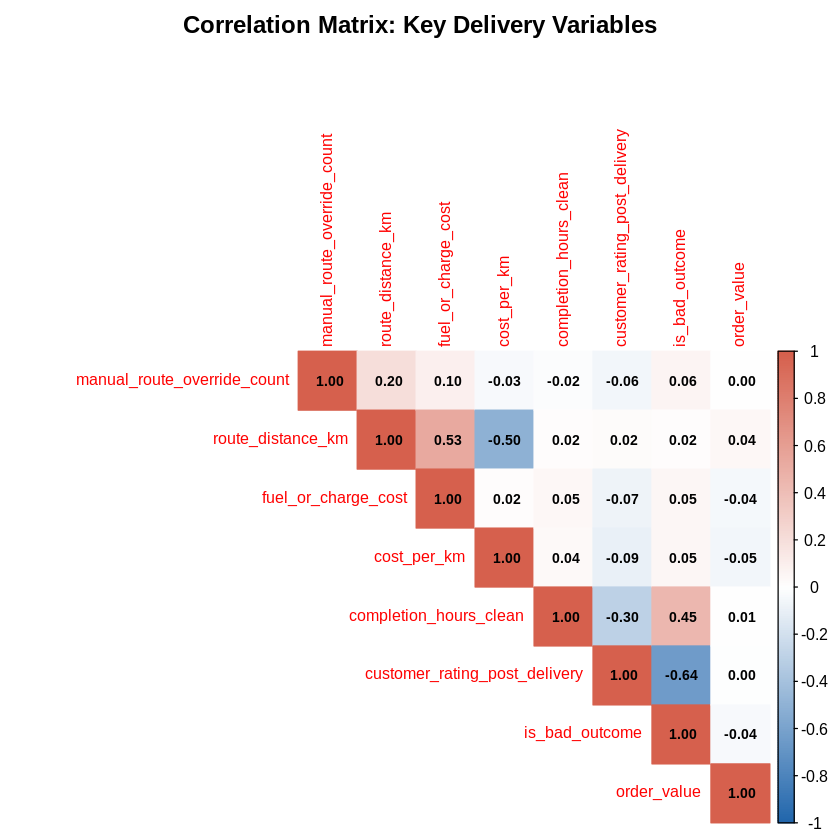

In [74]:
# Visualise the correlation matrix
png(paste0(OUTPUT_PATH, 'figure_01_correlation_matrix.png'), width = 900, height = 800, res = 120)
corrplot(
  corr_matrix,
  method = 'color',
  type = 'upper',
  tl.cex = 0.8,
  addCoef.col = 'black',
  number.cex = 0.7,
  col = colorRampPalette(c('#2166ac', 'white', '#d6604d'))(200),
  title = 'Correlation Matrix: Key Delivery Variables',
  mar = c(0, 0, 2, 0)
)
dev.off()

# Also display inline
corrplot(
  corr_matrix,
  method = 'color',
  type = 'upper',
  tl.cex = 0.8,
  addCoef.col = 'black',
  number.cex = 0.7,
  col = colorRampPalette(c('#2166ac', 'white', '#d6604d'))(200),
  title = 'Correlation Matrix: Key Delivery Variables',
  mar = c(0, 0, 2, 0)
)

cat('\nInterpretation: The correlation matrix shows pairwise relationships between numerical delivery variables. Strong positive correlations between route distance and fuel cost are expected. Any meaningful correlation between is_bad_outcome and manual_route_override_count would support the case study concern that route disruption is linked to service failure. Negative correlations between customer_rating and is_bad_outcome confirm that failed or delayed services receive lower ratings.\n')

---
## **Visualisation 1 - Customer Complaints by Complaint Type**

This bar chart shows the most common complaint categories across the 320 complaint records. It directly addresses the case study concern that customer complaints have increased and that the company cannot properly connect customer experience issues with operational records.

complaint_type,complaint_count,complaint_pct
<chr>,<int>,<dbl>
Delay,101,31.6
MissedPickup,64,20.0
AppIssue,53,16.6
DriverBehaviour,51,15.9
SupportExperience,20,6.2
Billing,16,5.0
Damage,15,4.7



Interpretation: Delay is the most frequently reported complaint type, followed by MissedPickup and AppIssue. This is consistent with the case study description of rising delays, missed delivery windows, and growing platform reliability problems. The presence of AppIssue as a top complaint type also supports the technology director concern about inadequate data infrastructure.


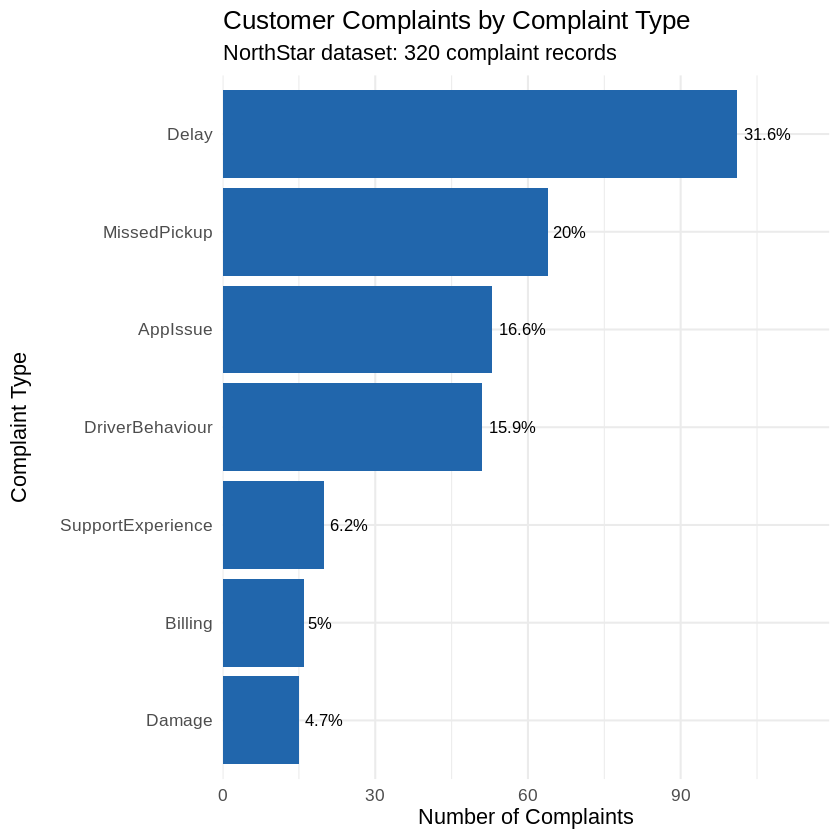

In [75]:
complaint_type_summary <- complaints %>%
  count(complaint_type, name = 'complaint_count') %>%
  mutate(complaint_pct = round(100 * complaint_count / sum(complaint_count), 1)) %>%
  arrange(desc(complaint_count))

complaint_type_summary

p1 <- ggplot(complaint_type_summary,
             aes(x = reorder(complaint_type, complaint_count), y = complaint_count)) +
  geom_col(fill = '#2166ac') +
  geom_text(aes(label = paste0(complaint_pct, '%')), hjust = -0.15, size = 3.5) +
  coord_flip() +
  scale_y_continuous(expand = expansion(mult = c(0, 0.18))) +
  labs(
    title    = 'Customer Complaints by Complaint Type',
    subtitle = 'NorthStar dataset: 320 complaint records',
    x        = 'Complaint Type',
    y        = 'Number of Complaints'
  ) +
  theme_minimal(base_size = 13)

print(p1)
ggsave(paste0(OUTPUT_PATH, 'figure_02_complaint_types.png'), plot = p1, width = 8, height = 5, dpi = 300)

cat('\nInterpretation: Delay is the most frequently reported complaint type, followed by MissedPickup and AppIssue. This is consistent with the case study description of rising delays, missed delivery windows, and growing platform reliability problems. The presence of AppIssue as a top complaint type also supports the technology director concern about inadequate data infrastructure.\n')

---
## **Visualisation 2 - Bad Outcome Rate by Pickup Zone**

This chart compares the percentage of delayed or failed deliveries across pickup zones. It directly addresses the case study statement that some city zones consistently perform worse than others.

pickup_zone_clean,total_orders,delivery_records,bad_outcomes,complaints,avg_completion_hours,avg_cost_per_km,avg_rating,avg_manual_overrides,bad_outcome_rate,complaint_rate,bad_outcome_pct,complaint_pct
<chr>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Central,238,174,84,56,11.245158,1.3239626,3.546036,1.2931034,0.4827586,0.2352941,48.3,23.5
Airport,144,113,43,28,9.648656,0.6160882,3.984037,1.8053097,0.3805310,0.1944444,38.1,19.4
Riverside,151,119,43,39,10.756360,1.4179001,3.864492,0.7310924,0.3613445,0.2582781,36.1,25.8
East,207,156,50,46,10.428183,1.3592723,3.912078,0.7884615,0.3205128,0.2222222,32.1,22.2
North,174,135,43,50,9.785670,1.3380753,3.896667,0.6962963,0.3185185,0.2873563,31.9,28.7
West,155,114,35,26,10.160827,1.2481043,3.896316,0.8070175,0.3070175,0.1677419,30.7,16.8
South,181,139,36,40,9.848314,1.4020914,4.051825,0.6906475,0.2589928,0.2209945,25.9,22.1



Interpretation: Central and Airport zones have the highest bad outcome rates, while South has the lowest. This supports the operations director concern about inconsistent zone performance. Central zone also has the highest number of manual route overrides according to the zone performance summary, which may be a contributing factor.


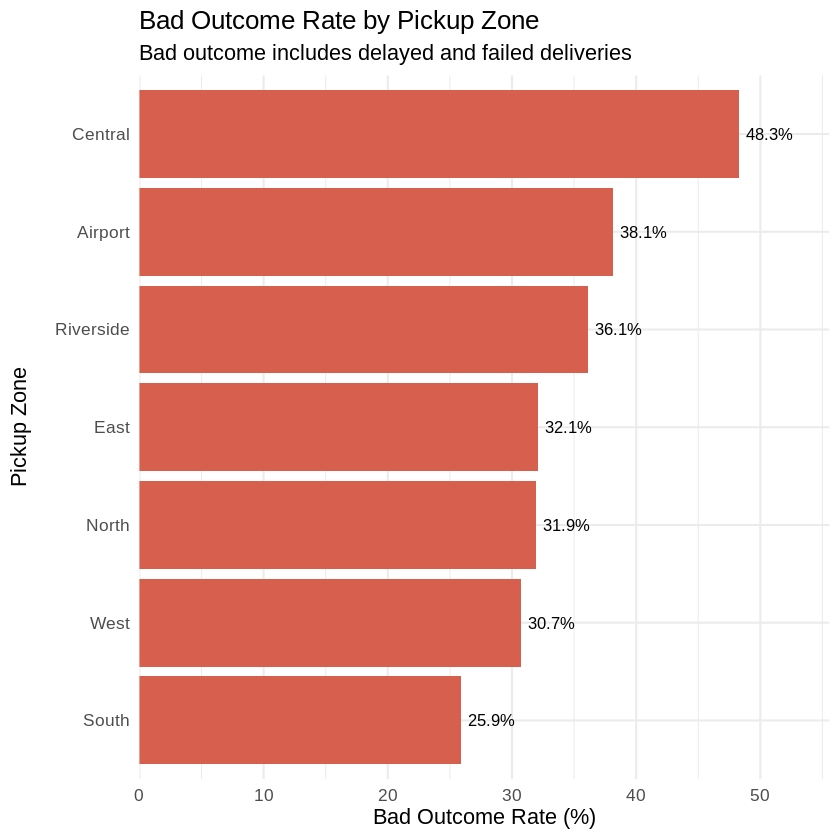

In [76]:
zone_plot_df <- zone_perf %>%
  mutate(
    bad_outcome_pct  = round(bad_outcome_rate * 100, 1),
    complaint_pct    = round(complaint_rate   * 100, 1)
  ) %>%
  arrange(desc(bad_outcome_pct))

zone_plot_df

p2 <- ggplot(zone_plot_df,
             aes(x = reorder(pickup_zone_clean, bad_outcome_pct), y = bad_outcome_pct)) +
  geom_col(fill = '#d6604d') +
  geom_text(aes(label = paste0(bad_outcome_pct, '%')), hjust = -0.15, size = 3.5) +
  coord_flip() +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(
    title    = 'Bad Outcome Rate by Pickup Zone',
    subtitle = 'Bad outcome includes delayed and failed deliveries',
    x        = 'Pickup Zone',
    y        = 'Bad Outcome Rate (%)'
  ) +
  theme_minimal(base_size = 13)

print(p2)
ggsave(paste0(OUTPUT_PATH, 'figure_03_bad_outcome_by_zone.png'), plot = p2, width = 8, height = 5, dpi = 300)

cat('\nInterpretation: Central and Airport zones have the highest bad outcome rates, while South has the lowest. This supports the operations director concern about inconsistent zone performance. Central zone also has the highest number of manual route overrides according to the zone performance summary, which may be a contributing factor.\n')

---
## **Visualisation 3 - Bad Outcome Rate by Hub**

This chart compares operational hubs by their bad outcome rate. The operations director in the case study believes underperforming hubs are a major part of the problem.

hub_id,hub_name,zone_clean,delivery_records,bad_outcomes,avg_completion_hours,avg_cost_per_km,avg_rating,avg_manual_overrides,bad_outcome_rate,bad_outcome_pct
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
H05,Central Core,Central,115,48,11.553300,1.477564,3.669558,0.9478261,0.4173913,41.7
H06,Airport Hub,Airport,104,42,9.917423,1.239235,3.882136,0.9134615,0.4038462,40.4
H08,Midtown Relay,Central,128,48,10.560490,1.181762,3.884560,1.1093750,0.3750000,37.5
H04,West Gate,West,127,44,11.102635,1.355406,3.915476,0.8740157,0.3464567,34.6
H02,South Link,South,106,36,9.478948,1.168068,3.950952,0.9150943,0.3396226,34.0
H07,Riverside Hub,Riverside,115,39,10.535888,1.222085,3.881858,1.0521739,0.3391304,33.9
H01,North Exchange,North,136,43,10.684968,1.371519,3.840593,1.0294118,0.3161765,31.6
H03,East Dock,East,119,34,8.437893,1.054579,3.895862,0.8907563,0.2857143,28.6



Interpretation: Central Core and Airport Hub have the highest bad outcome rates across all hubs. Both also show higher average completion times and cost per km in the hub performance summary. This is consistent with the case study description of hubs that appear efficient by volume but hide downstream service problems.


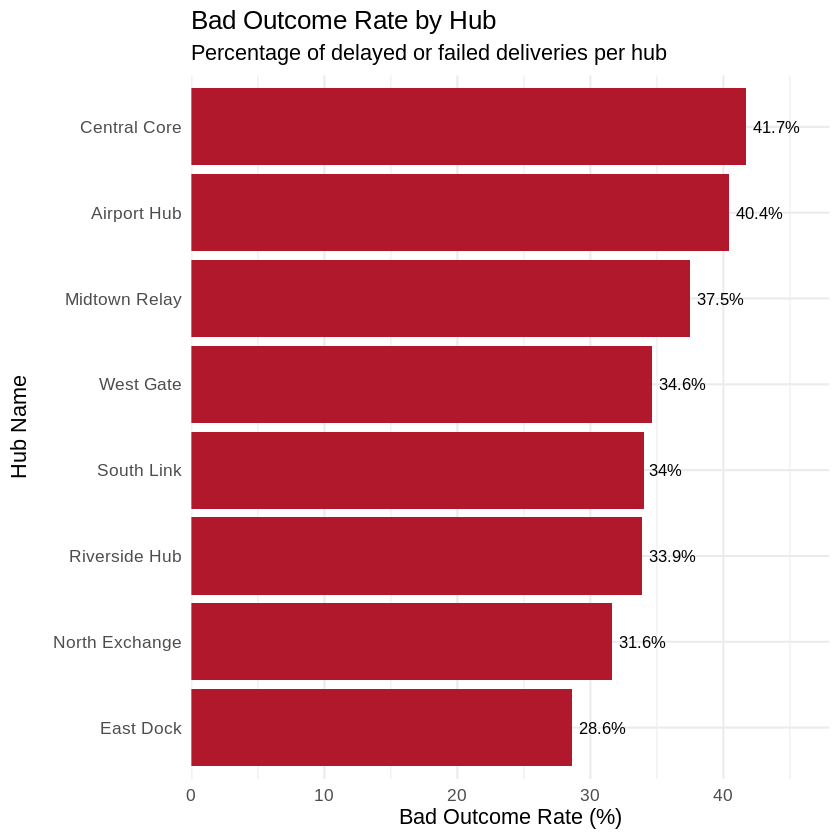

In [77]:
hub_plot_df <- hub_perf %>%
  mutate(bad_outcome_pct = round(bad_outcome_rate * 100, 1)) %>%
  arrange(desc(bad_outcome_pct))

hub_plot_df

p3 <- ggplot(hub_plot_df,
             aes(x = reorder(hub_name, bad_outcome_pct), y = bad_outcome_pct)) +
  geom_col(fill = '#b2182b') +
  geom_text(aes(label = paste0(bad_outcome_pct, '%')), hjust = -0.15, size = 3.5) +
  coord_flip() +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(
    title    = 'Bad Outcome Rate by Hub',
    subtitle = 'Percentage of delayed or failed deliveries per hub',
    x        = 'Hub Name',
    y        = 'Bad Outcome Rate (%)'
  ) +
  theme_minimal(base_size = 13)

print(p3)
ggsave(paste0(OUTPUT_PATH, 'figure_04_bad_outcome_by_hub.png'), plot = p3, width = 8, height = 5, dpi = 300)

cat('\nInterpretation: Central Core and Airport Hub have the highest bad outcome rates across all hubs. Both also show higher average completion times and cost per km in the hub performance summary. This is consistent with the case study description of hubs that appear efficient by volume but hide downstream service problems.\n')

---
## **Visualisation 4 - Delivery Outcome Percentage by Service Type**

This stacked proportional bar chart shows the share of on-time, delayed, and failed deliveries for each service type. It helps identify whether certain service lines are more exposed to operational risk.

service_type,delivery_status,records,outcome_pct
<chr>,<fct>,<int>,<dbl>
Business,NA,39,23.6
Business,Delayed,28,17.0
Business,Failed,25,15.2
Business,OnTime,73,44.2
Medical,NA,31,22.3
Medical,Delayed,22,15.8
Medical,Failed,16,11.5
Medical,OnTime,70,50.4
Parcel,NA,78,25.3



Interpretation: This chart shows whether certain service lines have a higher share of delays or failures. If Medical or Business services show disproportionately high failure rates, this would have both financial and reputational implications for NorthStar given the nature of those contracts.


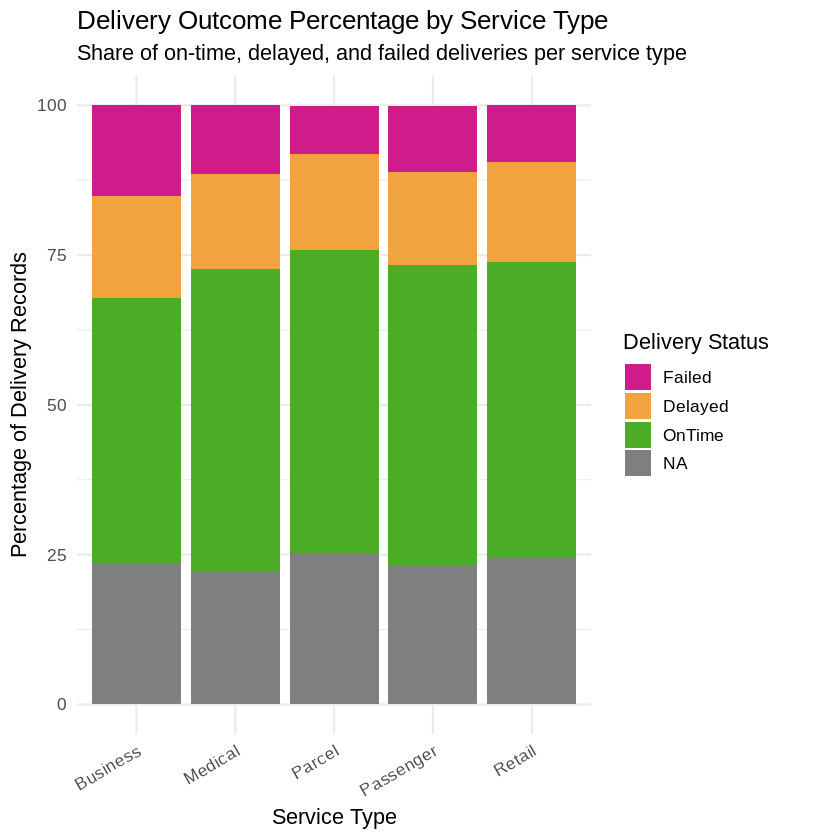

In [78]:
service_status_df <- ops_df %>%
  filter(!is.na(delivery_status)) %>%
  count(service_type, delivery_status, name = 'records') %>%
  group_by(service_type) %>%
  mutate(outcome_pct = round(100 * records / sum(records), 1)) %>%
  ungroup() %>%
  # Set factor order so OnTime appears at the bottom of the stacked bar
  mutate(delivery_status = factor(delivery_status, levels = c('Failed', 'Delayed', 'OnTime')))

service_status_df

p4 <- ggplot(service_status_df,
             aes(x = service_type, y = outcome_pct, fill = delivery_status)) +
  geom_col() +
  scale_fill_manual(values = c('OnTime' = '#4dac26', 'Delayed' = '#f1a340', 'Failed' = '#d01c8b')) +
  labs(
    title    = 'Delivery Outcome Percentage by Service Type',
    subtitle = 'Share of on-time, delayed, and failed deliveries per service type',
    x        = 'Service Type',
    y        = 'Percentage of Delivery Records',
    fill     = 'Delivery Status'
  ) +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

print(p4)
ggsave(paste0(OUTPUT_PATH, 'figure_05_outcome_by_service_type.png'), plot = p4, width = 9, height = 5, dpi = 300)

cat('\nInterpretation: This chart shows whether certain service lines have a higher share of delays or failures. If Medical or Business services show disproportionately high failure rates, this would have both financial and reputational implications for NorthStar given the nature of those contracts.\n')

---
## **Visualisation 5 - Cost per Km by Delivery Status**

This boxplot compares operating cost per km across on-time, delayed, and failed deliveries. The finance director is concerned that some service areas are unprofitable. If delayed or failed services also show higher costs, this provides useful evidence for the report.

delivery_status,records,mean_cost_per_km,median_cost_per_km,sd_cost_per_km,q25,q75
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Delayed,188,0.98,0.87,0.47,0.64,1.18
Failed,126,1.07,0.98,0.43,0.77,1.30
OnTime,588,1.04,0.93,0.48,0.69,1.26



Interpretation: If delayed or failed deliveries show higher median cost per km than on-time ones, this directly supports the finance director concern. Higher costs in bad-outcome services suggest that operational failures are also creating unnecessary financial burden, not just service quality problems.


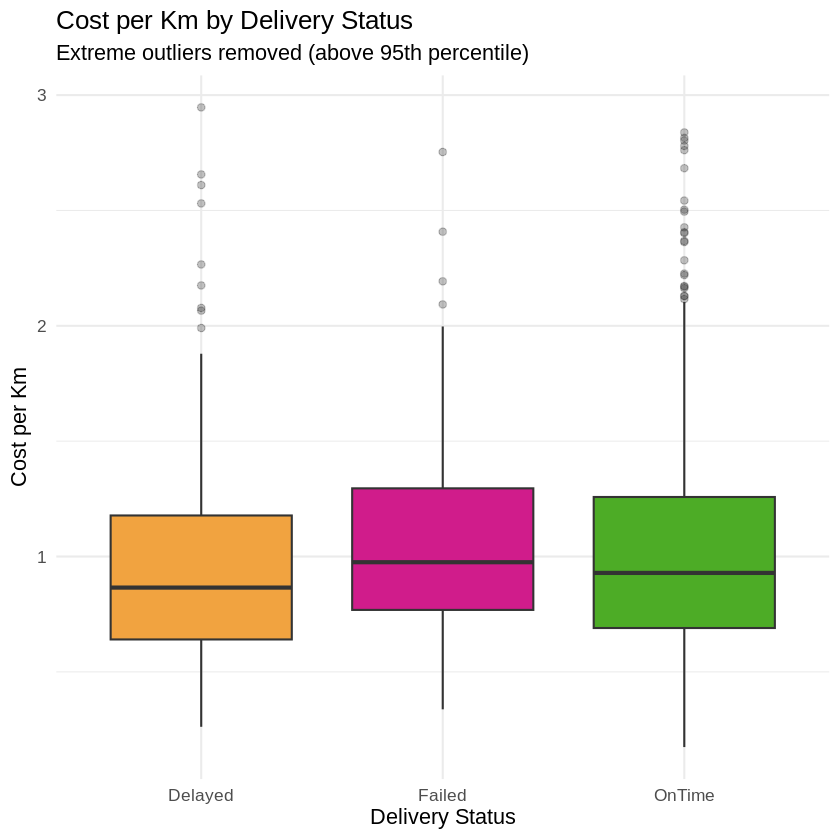

In [79]:
# Cap at 95th percentile to remove extreme outliers from the visual
cost_limit <- quantile(ops_df$cost_per_km, 0.95, na.rm = TRUE)

cost_plot_df <- ops_df %>%
  filter(!is.na(delivery_status), !is.na(cost_per_km), cost_per_km <= cost_limit)

# Numerical summary to accompany the chart
cost_summary <- cost_plot_df %>%
  group_by(delivery_status) %>%
  summarise(
    records            = n(),
    mean_cost_per_km   = round(mean(cost_per_km),   2),
    median_cost_per_km = round(median(cost_per_km), 2),
    sd_cost_per_km     = round(sd(cost_per_km),     2),
    q25                = round(quantile(cost_per_km, 0.25), 2),
    q75                = round(quantile(cost_per_km, 0.75), 2),
    .groups = 'drop'
  )

cost_summary

p5 <- ggplot(cost_plot_df,
             aes(x = delivery_status, y = cost_per_km, fill = delivery_status)) +
  geom_boxplot(outlier.alpha = 0.3) +
  scale_fill_manual(values = c('OnTime' = '#4dac26', 'Delayed' = '#f1a340', 'Failed' = '#d01c8b')) +
  labs(
    title    = 'Cost per Km by Delivery Status',
    subtitle = 'Extreme outliers removed (above 95th percentile)',
    x        = 'Delivery Status',
    y        = 'Cost per Km',
    fill     = 'Status'
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = 'none')

print(p5)
ggsave(paste0(OUTPUT_PATH, 'figure_06_cost_per_km_by_status.png'), plot = p5, width = 7, height = 5, dpi = 300)

cat('\nInterpretation: If delayed or failed deliveries show higher median cost per km than on-time ones, this directly supports the finance director concern. Higher costs in bad-outcome services suggest that operational failures are also creating unnecessary financial burden, not just service quality problems.\n')

---
## **Visualisation 6 - Manual Route Overrides and Customer Ratings**

This scatter plot with a linear trend line tests whether manual route overrides are associated with lower customer ratings. The case study specifically mentions that some drivers record unusually high override levels and that route allocation may be affecting performance.

delivery_status,records,mean_overrides,mean_rating
<chr>,<int>,<dbl>,<dbl>
Delayed,197,1.07,3.11
Failed,131,1.02,3.05
OnTime,608,0.93,4.28


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'



Interpretation: If the trend line slopes downward within the Delayed or Failed panels, it suggests that higher override counts are associated with worse customer experience in already-poor deliveries. This would support the argument that route override behaviour is not simply a neutral operational response but may reflect deeper planning problems.


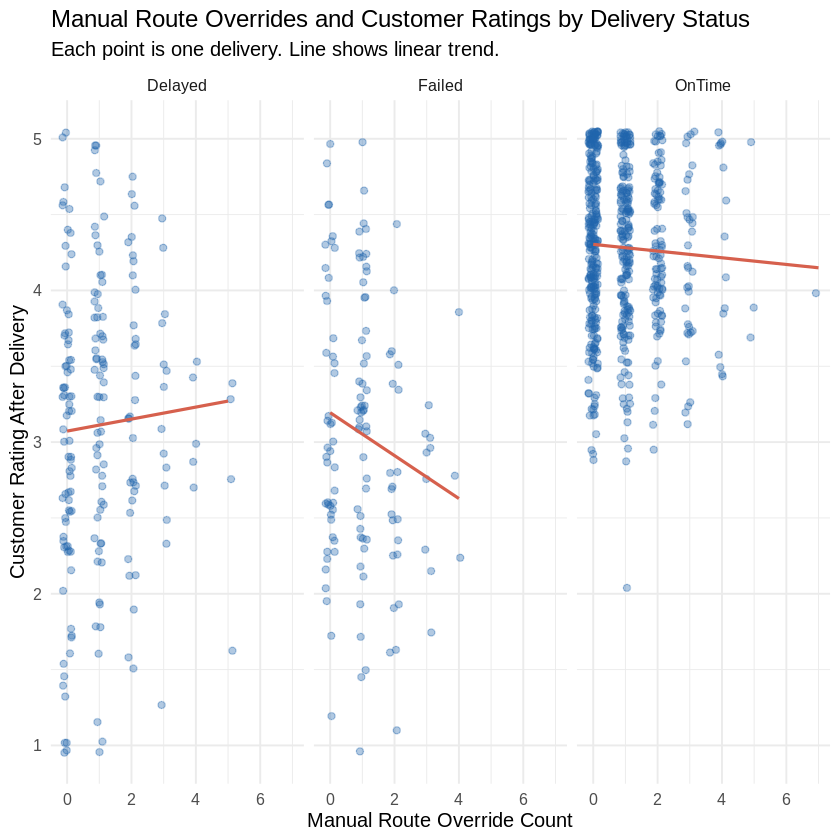

In [80]:
override_plot_df <- ops_df %>%
  filter(!is.na(delivery_status),
         !is.na(manual_route_override_count),
         !is.na(customer_rating_post_delivery))

# Numerical summary
override_summary <- override_plot_df %>%
  group_by(delivery_status) %>%
  summarise(
    records              = n(),
    mean_overrides       = round(mean(manual_route_override_count),   2),
    mean_rating          = round(mean(customer_rating_post_delivery), 2),
    .groups = 'drop'
  )

override_summary

p6 <- ggplot(override_plot_df,
             aes(x = manual_route_override_count, y = customer_rating_post_delivery)) +
  geom_jitter(width = 0.15, height = 0.05, alpha = 0.35, colour = '#2166ac') +
  geom_smooth(method = 'lm', se = FALSE, colour = '#d6604d', linewidth = 0.9) +
  facet_wrap(~ delivery_status) +
  labs(
    title    = 'Manual Route Overrides and Customer Ratings by Delivery Status',
    subtitle = 'Each point is one delivery. Line shows linear trend.',
    x        = 'Manual Route Override Count',
    y        = 'Customer Rating After Delivery'
  ) +
  theme_minimal(base_size = 12)

print(p6)
ggsave(paste0(OUTPUT_PATH, 'figure_07_overrides_vs_rating.png'), plot = p6, width = 10, height = 5, dpi = 300)

cat('\nInterpretation: If the trend line slopes downward within the Delayed or Failed panels, it suggests that higher override counts are associated with worse customer experience in already-poor deliveries. This would support the argument that route override behaviour is not simply a neutral operational response but may reflect deeper planning problems.\n')

---
## **Visualisation 7 - Monthly Trend of Orders and Complaints**

This line chart compares monthly order volume with monthly complaint volume. The case study says complaints have increased sharply. This chart helps show whether complaint levels rise in proportion to demand or whether they grow separately from order volume.


Interpretation: If complaint counts remain relatively stable while order volumes fluctuate, it suggests complaint rates are dropping. If complaints rise alongside orders or outpace them, this would confirm the case study claim that NorthStar is losing its ability to maintain service quality as demand grows.


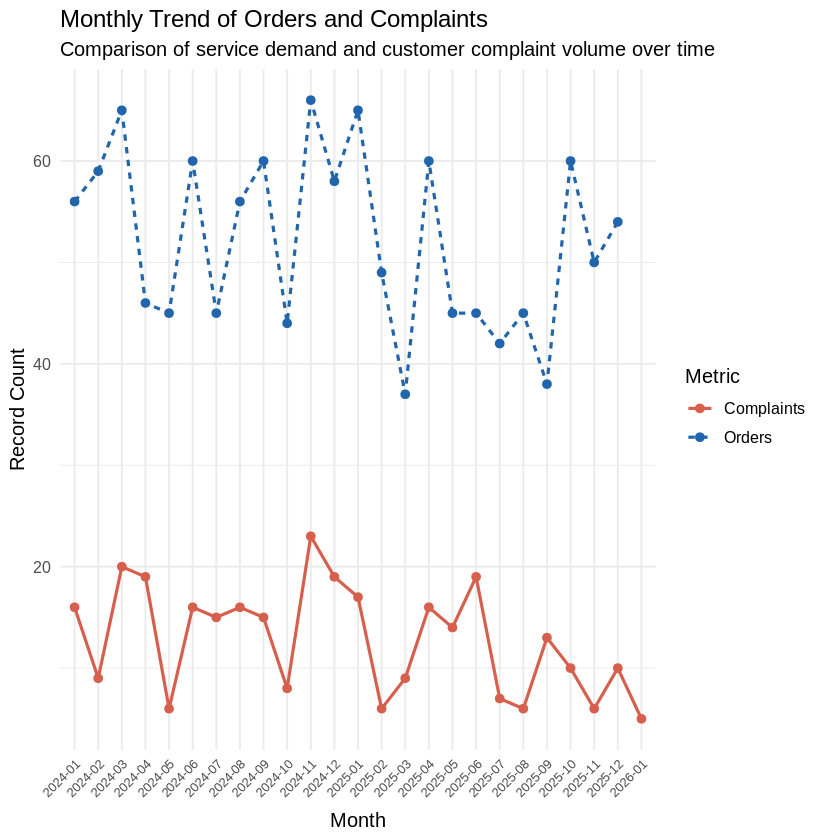

In [81]:
monthly_orders <- orders %>%
  filter(!is.na(order_month)) %>%
  count(order_month, name = 'count') %>%
  rename(month = order_month) %>%
  mutate(metric = 'Orders')

monthly_complaints <- complaints %>%
  filter(!is.na(complaint_month)) %>%
  count(complaint_month, name = 'count') %>%
  rename(month = complaint_month) %>%
  mutate(metric = 'Complaints')

monthly_trend <- bind_rows(monthly_orders, monthly_complaints) %>%
  arrange(month, metric)

p7 <- ggplot(monthly_trend,
             aes(x = month, y = count, group = metric,
                 colour = metric, linetype = metric)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  scale_colour_manual(values = c('Orders' = '#2166ac', 'Complaints' = '#d6604d')) +
  labs(
    title    = 'Monthly Trend of Orders and Complaints',
    subtitle = 'Comparison of service demand and customer complaint volume over time',
    x        = 'Month',
    y        = 'Record Count',
    colour   = 'Metric',
    linetype = 'Metric'
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 8))

print(p7)
ggsave(paste0(OUTPUT_PATH, 'figure_08_monthly_trend.png'), plot = p7, width = 11, height = 5, dpi = 300)

cat('\nInterpretation: If complaint counts remain relatively stable while order volumes fluctuate, it suggests complaint rates are dropping. If complaints rise alongside orders or outpace them, this would confirm the case study claim that NorthStar is losing its ability to maintain service quality as demand grows.\n')

---
## **Visualisation 8 - App Event Latency by Event Type**

NorthStar's mobile platform is a core part of operations. High API latency for important app events such as ETA refresh, payment retry, and support escalation can directly worsen the customer experience. This chart ranks event types by average latency.

event_type,event_count,avg_latency_ms,median_latency_ms,success_rate_pct
<chr>,<int>,<dbl>,<dbl>,<dbl>
delivery_instruction_update,75,496,446,100.0
chat_escalated,38,478,411,50.0
chat_opened,88,478,416,100.0
payment_retry,69,473,440,72.5
track_order,138,461,427,100.0
search_route,99,457,457,100.0
eta_refresh,105,452,440,100.0
cancel_attempt,28,417,414,100.0



Interpretation: Event types that appear at the top of this chart have higher average latency and may be responsible for the AppIssue complaints identified in the complaint analysis. If high-latency events include customer-facing actions such as ETA tracking, payment retries, or chat escalation, this is relevant evidence for both the customer experience and the technology directors in the case study.


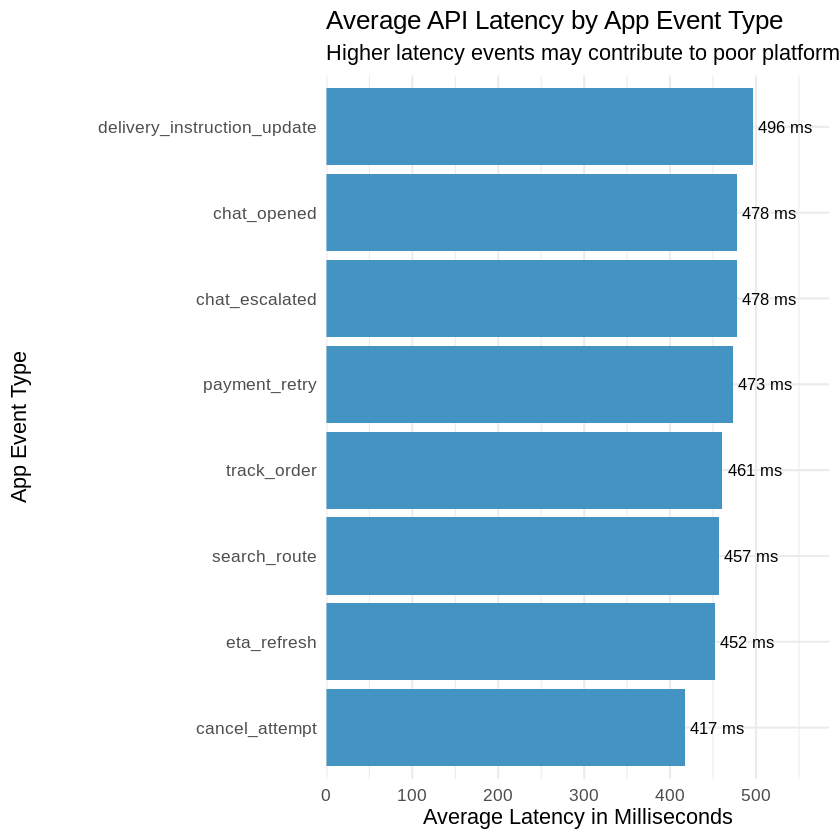

In [82]:
app_event_summary <- app_events %>%
  group_by(event_type) %>%
  summarise(
    event_count        = n(),
    avg_latency_ms     = round(mean(api_latency_ms,  na.rm = TRUE), 0),
    median_latency_ms  = round(median(api_latency_ms, na.rm = TRUE), 0),
    success_rate_pct   = round(100 * mean(success_flag, na.rm = TRUE), 1),
    .groups = 'drop'
  ) %>%
  arrange(desc(avg_latency_ms))

app_event_summary

p8 <- ggplot(app_event_summary,
             aes(x = reorder(event_type, avg_latency_ms), y = avg_latency_ms)) +
  geom_col(fill = '#4393c3') +
  geom_text(aes(label = paste0(avg_latency_ms, ' ms')), hjust = -0.1, size = 3.5) +
  coord_flip() +
  scale_y_continuous(expand = expansion(mult = c(0, 0.18))) +
  labs(
    title    = 'Average API Latency by App Event Type',
    subtitle = 'Higher latency events may contribute to poor platform experience',
    x        = 'App Event Type',
    y        = 'Average Latency in Milliseconds'
  ) +
  theme_minimal(base_size = 13)

print(p8)
ggsave(paste0(OUTPUT_PATH, 'figure_09_app_event_latency.png'), plot = p8, width = 8, height = 5, dpi = 300)

cat('\nInterpretation: Event types that appear at the top of this chart have higher average latency and may be responsible for the AppIssue complaints identified in the complaint analysis. If high-latency events include customer-facing actions such as ETA tracking, payment retries, or chat escalation, this is relevant evidence for both the customer experience and the technology directors in the case study.\n')

---
## **Visualisation 9 - Incident Type Frequency**

This chart shows the most common incident types across the 280 incident records. Understanding what kinds of incidents occur most often helps identify systemic problems in vehicle management, driver behaviour, and route execution.

incident_type,incident_count,incident_pct
<chr>,<int>,<dbl>
ProofMissing,46,16.4
CustomerNoShow,44,15.7
RouteDeviation,43,15.4
VehicleFault,37,13.2
BatteryAlert,36,12.9
AppSyncError,31,11.1
TemperatureIssue,29,10.4
SafetyNearMiss,14,5.0



Interpretation: The most frequent incident types reveal where operational problems are concentrated. BatteryAlert and VehicleFault incidents are consistent with the case study warning that vehicle maintenance issues are being detected too late because fault events and route assignments are not analysed together. ProofMissing and AppSyncError incidents connect directly to the data and platform reliability concerns raised by the technology director.


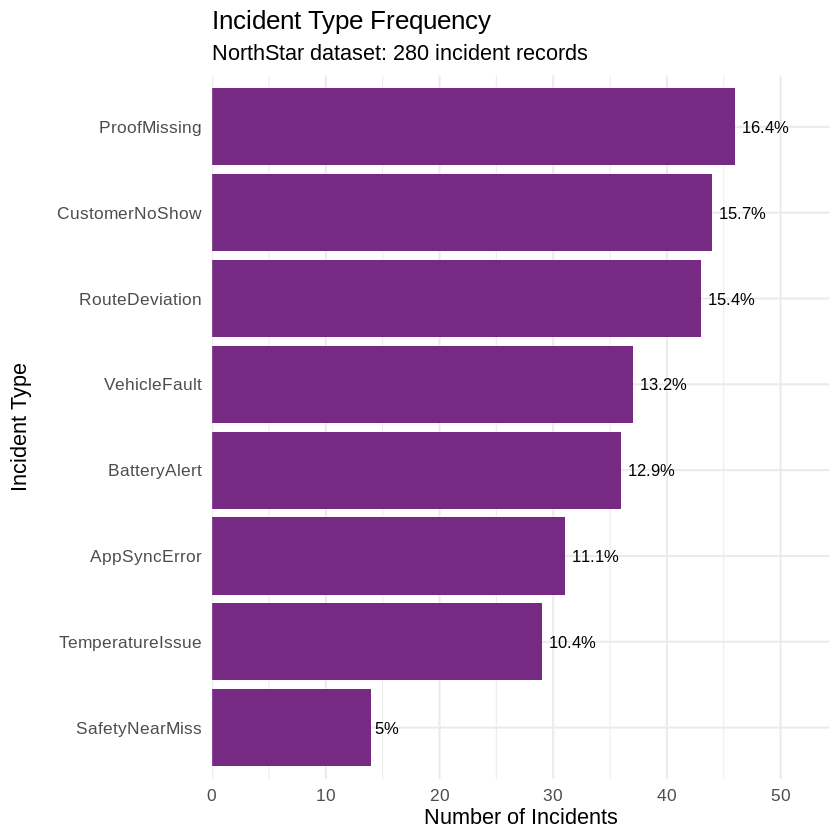

In [83]:
incident_summary <- incidents %>%
  count(incident_type, name = 'incident_count') %>%
  mutate(incident_pct = round(100 * incident_count / sum(incident_count), 1)) %>%
  arrange(desc(incident_count))

incident_summary

p9 <- ggplot(incident_summary,
             aes(x = reorder(incident_type, incident_count), y = incident_count)) +
  geom_col(fill = '#762a83') +
  geom_text(aes(label = paste0(incident_pct, '%')), hjust = -0.15, size = 3.5) +
  coord_flip() +
  scale_y_continuous(expand = expansion(mult = c(0, 0.18))) +
  labs(
    title    = 'Incident Type Frequency',
    subtitle = 'NorthStar dataset: 280 incident records',
    x        = 'Incident Type',
    y        = 'Number of Incidents'
  ) +
  theme_minimal(base_size = 13)

print(p9)
ggsave(paste0(OUTPUT_PATH, 'figure_10_incident_types.png'), plot = p9, width = 8, height = 5, dpi = 300)

cat('\nInterpretation: The most frequent incident types reveal where operational problems are concentrated. BatteryAlert and VehicleFault incidents are consistent with the case study warning that vehicle maintenance issues are being detected too late because fault events and route assignments are not analysed together. ProofMissing and AppSyncError incidents connect directly to the data and platform reliability concerns raised by the technology director.\n')

---
## **Save R Analytics Summary Tables and Archive Outputs**

The key summary tables and chart images are saved locally in Colab. The output folder is zipped as coursework evidence under `Outputs/R_Outputs`.

In [84]:
write.csv(delivery_summary,      paste0(OUTPUT_PATH, 'R_delivery_status_summary.csv'),   row.names = FALSE)
write.csv(complaint_type_summary,paste0(OUTPUT_PATH, 'R_complaint_type_summary.csv'),    row.names = FALSE)
write.csv(zone_plot_df,          paste0(OUTPUT_PATH, 'R_zone_visual_summary.csv'),        row.names = FALSE)
write.csv(hub_plot_df,           paste0(OUTPUT_PATH, 'R_hub_visual_summary.csv'),         row.names = FALSE)
write.csv(service_status_df,     paste0(OUTPUT_PATH, 'R_service_status_summary.csv'),     row.names = FALSE)
write.csv(cost_summary,          paste0(OUTPUT_PATH, 'R_cost_status_summary.csv'),        row.names = FALSE)
write.csv(override_summary,      paste0(OUTPUT_PATH, 'R_override_rating_summary.csv'),    row.names = FALSE)
write.csv(monthly_trend,         paste0(OUTPUT_PATH, 'R_monthly_orders_complaints.csv'),  row.names = FALSE)
write.csv(app_event_summary,     paste0(OUTPUT_PATH, 'R_app_event_summary.csv'),          row.names = FALSE)
write.csv(incident_summary,      paste0(OUTPUT_PATH, 'R_incident_type_summary.csv'),      row.names = FALSE)
write.csv(as.data.frame(corr_matrix), paste0(OUTPUT_PATH, 'R_correlation_matrix.csv'),    row.names = TRUE)

cat('R analytics outputs saved locally in Colab:\n')
cat(OUTPUT_PATH, '\n\n')
print(list.files(OUTPUT_PATH))

zip_file <- '/content/northstar_r_outputs.zip'
if (file.exists(zip_file)) {
  file.remove(zip_file)
}

old_wd <- getwd()
setwd('/content')
utils::zip(zipfile = zip_file, files = 'northstar_r_outputs')
setwd(old_wd)

cat('\nOutput zip created:\n')
cat(zip_file, '\n')


R analytics outputs saved locally in Colab:
/content/northstar_r_outputs/ 

 [1] "figure_01_correlation_matrix.png"     
 [2] "figure_02_complaint_types.png"        
 [3] "figure_03_bad_outcome_by_zone.png"    
 [4] "figure_04_bad_outcome_by_hub.png"     
 [5] "figure_05_outcome_by_service_type.png"
 [6] "figure_06_cost_per_km_by_status.png"  
 [7] "figure_07_overrides_vs_rating.png"    
 [8] "figure_08_monthly_trend.png"          
 [9] "figure_09_app_event_latency.png"      
[10] "figure_10_incident_types.png"         
[11] "R_app_event_summary.csv"              
[12] "R_complaint_type_summary.csv"         
[13] "r_correlation_matrix.csv"             
[14] "R_correlation_matrix.csv"             
[15] "R_cost_status_summary.csv"            
[16] "R_delivery_status_summary.csv"        
[17] "R_hub_visual_summary.csv"             
[18] "R_incident_type_summary.csv"          
[19] "R_monthly_orders_complaints.csv"      
[20] "R_override_rating_summary.csv"        
[21] "R_service_status_s

[1] TRUE


Output zip created:
/content/northstar_r_outputs.zip 


## **Summary of SQL in R and R Analytics**

The SQL section queried the cleaned NorthStar data using filtering, joins, aggregation, CRUD operations on a temporary table, and an SQL index demonstration. The R analytics section added statistical summaries, correlation analysis, and visualisations for complaints, zones, hubs, service types, costs, app events, incidents, and operational trends. Together, these sections provide structured evidence for NorthStar's operational and customer experience issues.